# Análisis predictivo de riesgo de devolución en e-commerce

Este notebook conecta con la vista `gold.return_probability_features` en PostgreSQL para construir un modelo de clasificación simple y profesional con el menor código necesario.

In [ ]:
# Importación mínima y configuración
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sqlalchemy import create_engine

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(style="whitegrid")

# Cargar variables de entorno desde la raíz del proyecto
project_root = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
load_dotenv(project_root / ".env")

# Conexión a PostgreSQL usando únicamente las variables externas del proyecto
engine = create_engine(
    f"postgresql+psycopg2://{os.getenv('EXTERNAL_DB_USER')}:{os.getenv('EXTERNAL_DB_PASSWORD')}"
    f"@{os.getenv('EXTERNAL_DB_HOST')}:{os.getenv('EXTERNAL_DB_PORT')}/{os.getenv('EXTERNAL_DB_NAME')}"
)

query = "SELECT * FROM gold.return_probability_features"
df = pd.read_sql(query, engine)

for col in ["customer_id", "total_orders", "total_returns", "return_rate", "avg_spent"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["total_orders", "total_returns", "return_rate", "avg_spent"]).copy()

print(df.head())
print(f"\nFilas cargadas: {df.shape[0]}")

   customer_id  total_orders  total_returns  return_rate  avg_spent
0          NaN        131642            222     0.001686   4.488015
1      16592.0           222              6     0.027027   2.229505
2      13527.0           218              1     0.004587   2.804404
3      14173.0            29              0     0.000000   4.376897
4      12502.0           142              0     0.000000   5.665563

Filas cargadas: 4363


## 1. Distribuciones de las variables principales

Este gráfico muestra cómo se comportan las variables del dataset. Ayuda a identificar la forma de la distribución, la presencia de valores atípicos y la tendencia central de cada característica.

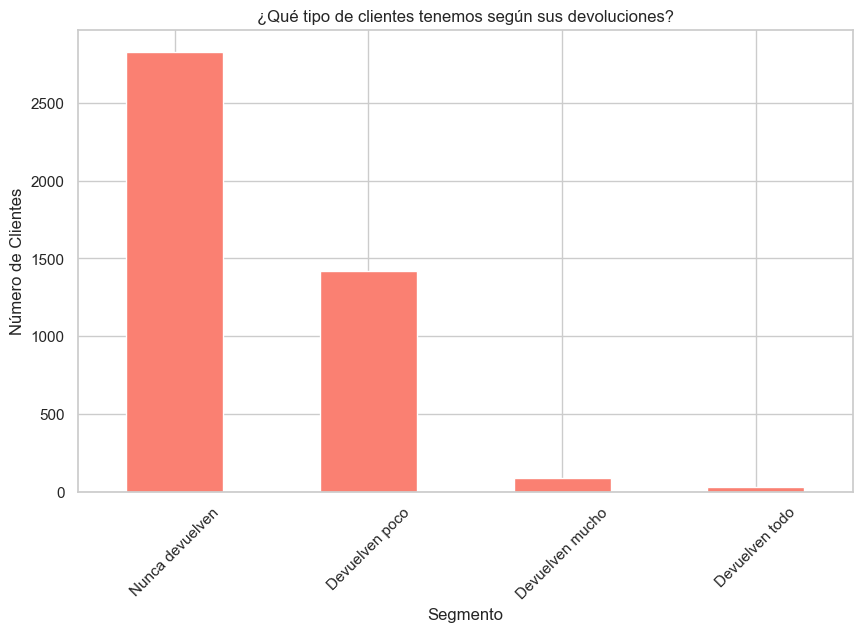

In [54]:
# Definimos grupos sencillos
df['segmento'] = pd.cut(df['return_rate'], 
                        bins=[-0.1, 0.0, 0.2, 0.8, 1.0], 
                        labels=['Nunca devuelven', 'Devuelven poco', 'Devuelven mucho', 'Devuelven todo'])

# Contamos cuántos clientes hay en cada uno
conteo = df['segmento'].value_counts().sort_index()

# Graficamos
plt.figure(figsize=(10, 6))
conteo.plot(kind='bar', color='salmon')
plt.title("¿Qué tipo de clientes tenemos según sus devoluciones?")
plt.xlabel("Segmento")
plt.ylabel("Número de Clientes")
plt.xticks(rotation=45)
plt.show()

## 2. Matriz de correlación

Este heatmap permite observar la relación entre las variables. Valores más intensos indican una asociación más fuerte, lo cual es útil para detectar redundancias o patrones relevantes antes de entrenar el modelo.

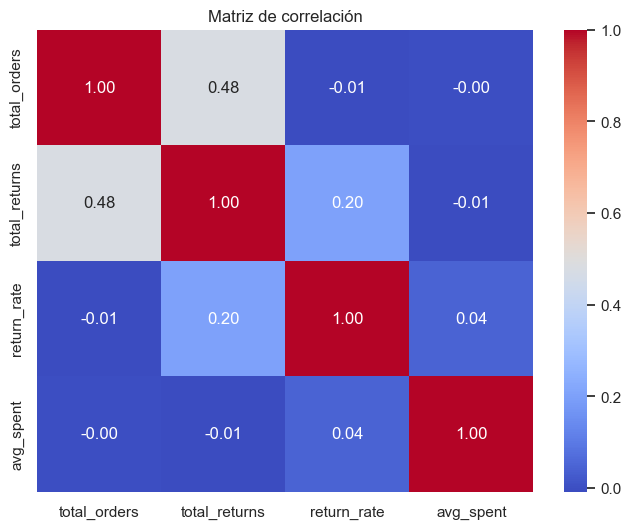

In [40]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

## 3. Ingeniería del target

Esta etapa convierte la tasa de devolución en una variable binaria que representa riesgo. La definición usada es simple: un cliente se considera de alto riesgo cuando su `return_rate` supera el 15%.

In [58]:
# Ingeniería del target — sin leakage
df["is_high_risk"] = (
    (df["total_returns"] >= 2) & (df["return_rate"] > 0.05)
).astype(int)

print(f"Proporción de clientes de alto riesgo: {df['is_high_risk'].mean():.2%}")

features = ["total_orders", "avg_spent"]
X = df[features]
y = df["is_high_risk"]
print(df[["return_rate", "is_high_risk"]].head())
print(f"Proporción de clientes de alto riesgo: {y.mean():.2%}")



Proporción de clientes de alto riesgo: 11.28%
   return_rate  is_high_risk
0     0.001686             0
1     0.027027             0
2     0.004587             0
3     0.000000             0
4     0.000000             0
Proporción de clientes de alto riesgo: 11.28%


## 4. Entrenamiento del modelo predictivo

Este bloque entrena un Random Forest para aprender patrones de comportamiento asociados a clientes de alto riesgo. El modelo usa las variables de comportamiento del cliente como insumo para la clasificación.

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced_subsample")
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

## 5. Evaluación del modelo

La matriz de confusión permite verificar cuántas predicciones fueron correctas y cuántas se equivocaron, mientras que el reporte de clasificación resume métricas clave como precisión, recall y F1-score.

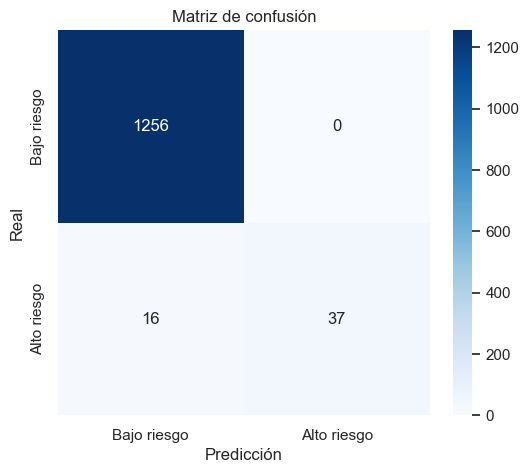


Reporte de clasificación:

              precision    recall  f1-score   support

 Bajo riesgo       0.99      1.00      0.99      1256
 Alto riesgo       1.00      0.70      0.82        53

    accuracy                           0.99      1309
   macro avg       0.99      0.85      0.91      1309
weighted avg       0.99      0.99      0.99      1309



In [43]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Bajo riesgo", "Alto riesgo"], yticklabels=["Bajo riesgo", "Alto riesgo"])
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()
  
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred, target_names=["Bajo riesgo", "Alto riesgo"]))

## 6. Importancia de las variables

Este gráfico muestra qué características tuvieron mayor influencia en la predicción del modelo. Es especialmente útil para interpretar el comportamiento del algoritmo y comunicar los hallazgos de negocio.


Importancia de las características:
 total_returns    0.621652
total_orders     0.273584
avg_spent        0.104765
dtype: float64


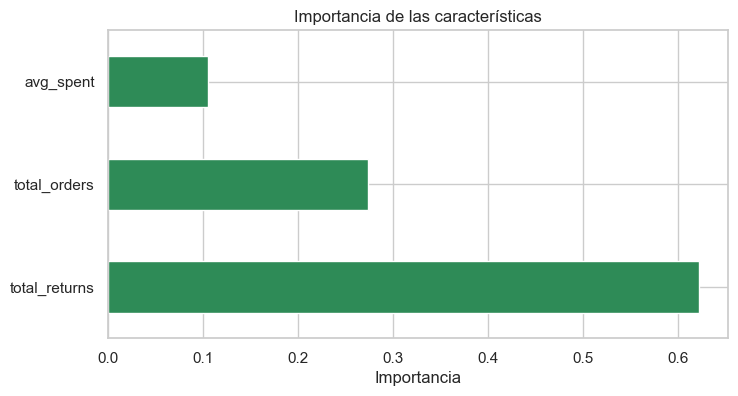

In [44]:
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print("\nImportancia de las características:\n", importance)
plt.figure(figsize=(8, 4))
importance.plot(kind="barh", color="seagreen")
plt.title("Importancia de las características")
plt.xlabel("Importancia")
plt.show()

## Conclusión

El modelo indica que las variables con mayor peso para identificar clientes de alto riesgo son las relacionadas con el historial de devoluciones, especialmente `total_returns` y `total_orders`. En general, cuanto mayor es ese historial, mayor es la probabilidad de que un cliente sea clasificado como alto riesgo.

### Resumen ejecutivo de negocio
- Los clientes con mayor cantidad de devoluciones representan el principal señal de riesgo.
- El número de pedidos también aporta información valiosa, aunque en menor medida.
- El gasto promedio ayuda a completar el perfil, pero no es la variable dominante.
- Este tipo de modelo puede apoyar decisiones de prevención, seguimiento y gestión de riesgo comercial.

## Explicación detallada de cada bloque del análisis predictivo

### 1. Carga de datos y preparación inicial
Este bloque conecta el notebook con la vista `gold.return_probability_features` en PostgreSQL y trae las variables clave: `customer_id`, `total_orders`, `total_returns`, `return_rate` y `avg_spent`. Su objetivo es garantizar que el análisis trabaje con datos limpios y listos para modelar. También convierte las columnas a tipo numérico y elimina registros incompletos para evitar sesgos en el entrenamiento.

### 2. Distribuciones de las variables principales
Esta sección muestra gráficas de distribución para cada característica. Sirve para entender cómo se comporta cada variable, si tiene valores extremos o si está muy concentrada. Desde un punto de vista de negocio, esto ayuda a detectar si ciertos clientes tienen perfiles muy distintos y si el comportamiento de devoluciones está concentrado en un segmento pequeño.

### 3. Matriz de correlación
La matriz de correlación muestra la relación entre las variables. Si dos variables se mueven de forma muy similar, puede existir redundancia. Esto es importante porque un modelo más simple y robusto suele beneficiarse de variables que aportan información nueva y no se repitan demasiado.

### 4. Ingeniería del target
Aquí se crea la variable objetivo `is_high_risk`, definida como 1 cuando la tasa de devolución supera el 15%. Este paso es fundamental porque transforma el problema en una clasificación binaria: identificar si un cliente es de alto riesgo o no. Es una decisión de negocio y analítica porque define el umbral de riesgo.

### 5. Entrenamiento del modelo predictivo
En este bloque se entrena un Random Forest usando las variables de comportamiento del cliente para predecir si será de alto riesgo. El modelo aprende patrones a partir de ejemplos históricos y luego los aplica a nuevos casos. En términos prácticos, esto permite anticipar problemas antes de que se materialicen.

### 6. Evaluación del modelo
La matriz de confusión y el reporte de clasificación muestran qué tan bien el modelo predice. La precisión mide cuán confiables son las predicciones positivas, el recall mide qué tan bien detecta los casos reales de alto riesgo y el F1-score entrega un equilibrio entre ambas. Esto es clave para decidir si el modelo es útil en producción o necesita ajuste.

### 7. Importancia de las variables
Este bloque muestra qué variables influyeron más en la predicción. Permite interpretar el modelo y comprender qué señales son más relevantes para identificar clientes de alto riesgo. En el caso del análisis, las devoluciones históricas parecen ser la señal más importante.

### Qué decisiones se pueden tomar a partir de este análisis
- Identificar clientes de alto riesgo y priorizar acciones de seguimiento comercial.
- Diseñar campañas preventivas para clientes con historial de devoluciones frecuente.
- Ajustar políticas de devolución, condiciones de compra o comunicación para reducir pérdidas.
- Segmentar clientes para enfocar estrategias de retención o soporte.
- Usar el modelo como base para alertas operativas o reglas de negocio automatizadas.

### Recomendación final de experto
El mayor valor de este análisis no está solo en predecir, sino en anticipar. Si un cliente muestra señales tempranas de riesgo, la empresa puede actuar antes de que la devolución se convierta en una pérdida mayor. Por eso, este tipo de modelo debe usarse como apoyo para decisiones comerciales, operativas y de servicio al cliente.